In [1]:
PATH = "/dtu/projects/02613_2025/data/modified_swiss_dwellings/"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from os.path import join

In [3]:
# Load building IDs and pick a few to visualize
with open(join(PATH, 'building_ids.txt'), 'r') as f:
    all_ids = f.read().splitlines()

print(f"Total buildings: {len(all_ids)}")
print(f"First 10 IDs: {all_ids[:10]}")

Total buildings: 4571
First 10 IDs: ['10000', '10009', '10014', '10019', '10029', '10031', '10051', '10053', '10056', '10064']


In [4]:
def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy"))
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask

/tmp/ipykernel_1238680/4028677975.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


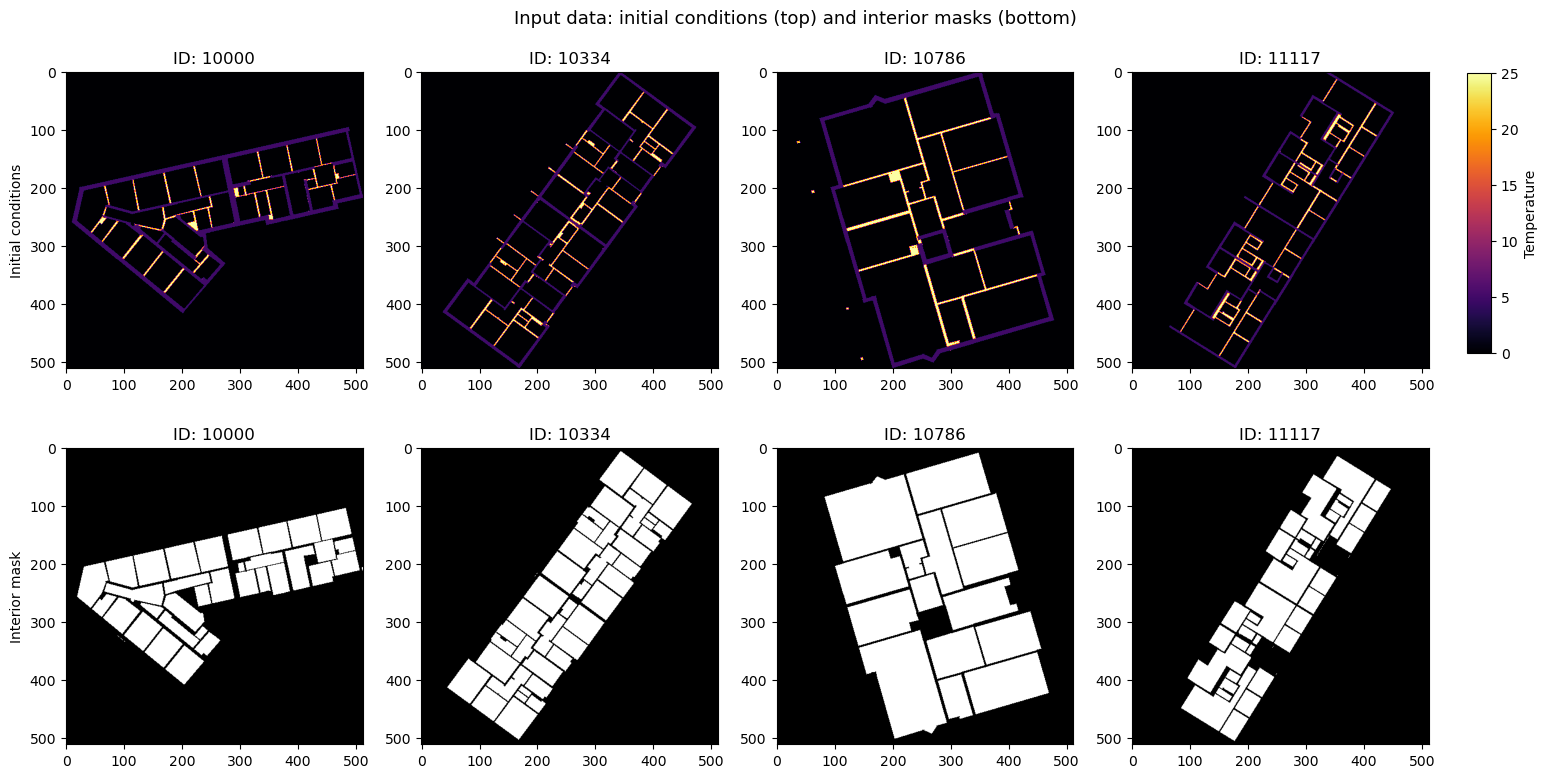

In [5]:
# Visualize domain (initial conditions) and interior mask for 4 buildings
building_ids = ['10000', '10334', '10786', '11117']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, bid in enumerate(building_ids):
    u, interior_mask = load_data(PATH, bid)

    # Top row: initial conditions (domain)
    im = axes[0, col].imshow(u[1:-1, 1:-1], cmap='inferno', vmin=0, vmax=25)
    axes[0, col].set_title(f'ID: {bid}')
    axes[0, col].axis('on')

    # Bottom row: interior mask
    axes[1, col].imshow(interior_mask, cmap='gray', vmin=0, vmax=1)
    axes[1, col].set_title(f'ID: {bid}')
    axes[1, col].axis('on')

# Shared colorbar for domain row
cbar_ax = fig.add_axes([0.92, 0.55, 0.015, 0.35])
fig.colorbar(im, cax=cbar_ax, label='Temperature')

axes[0, 0].set_ylabel('Initial conditions')
axes[1, 0].set_ylabel('Interior mask')

fig.suptitle('Input data: initial conditions (top) and interior masks (bottom)', fontsize=13)
plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig('floorplans_input.png', dpi=100, bbox_inches='tight')
plt.show()

In [6]:
# Inspect one building in detail
bid = '10000'
u, interior_mask = load_data(PATH, bid)

domain = u[1:-1, 1:-1]
print(f"Building {bid}")
print(f"  Grid shape: {domain.shape}")
print(f"  Unique values in domain: {np.unique(domain)}")
print(f"  Interior points: {interior_mask.sum()} / {interior_mask.size} ({100*interior_mask.mean():.1f}%)")

Building 10000
  Grid shape: (512, 512)
  Unique values in domain: [ 0.  5. 25.]
  Interior points: 55302 / 262144 (21.1%)
